# *Setup*

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
from numpy import format_float_positional as ffp
from scipy import stats
import pandas as pd
from time import perf_counter

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

from src.preprocessing import clean_data_modeling, get_transformers
from src.modeling import train_model, random_search_with_kfoldcv, parallelized_random_search_with_kfoldcv
from src.evaluation import evaluate, display_best_hyperparam_combinations
from src.utils import save_models, load_models

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_X, df_y = clean_data_modeling(df=df)
#df_X.to_csv('../data/processed/WA_Fn-UseC_-Telco-Customer-Churn_modeling_X.csv')
#df_y.to_csv('../data/processed/WA_Fn-UseC_-Telco-Customer-Churn_modeling_y.csv')

df_X_train, df_X_test, df_y_train, df_y_test = train_test_split(df_X, df_y, test_size=0.25, shuffle=True, stratify=df_y, random_state=7)
print('Dataset de Treinamento:', df_X_train.shape, df_y_train.shape)
print('Dataset de Testes:', df_X_test.shape, df_y_test.shape)

transformers_X, transformer_y = get_transformers(df_X=df_X, df_y=df_y)

models = {}

Dataset de Treinamento: (5282, 17) (5282, 1)
Dataset de Testes: (1761, 17) (1761, 1)


# Treinamento e Avaliação Individual dos Modelos

## ***Baseline***: Regressão Logística (**LR**)

In [3]:
X_train_transformed = transformers_X['LR'].fit_transform(df_X_train)
X_test_transformed = transformers_X['LR'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [4]:
models['LR'] = LogisticRegression(C=np.inf,
                                  tol=1e-4,
                                  fit_intercept=True,
                                  solver='lbfgs',
                                  max_iter=1000,
                                  n_jobs=1,
                                  random_state=7)

train_model(model=models['LR'],
            X=X_train_transformed, y=y_train.reshape(-1))

Tempo Total: 0 s | 0.0 min | 0.0 h
             0h 00min 00s


,Treinamento,Teste
Acurácia,0.808,0.810
Precisão,0.667,0.672
Recall,0.553,0.552
F1-Score,0.605,0.606
F2.-Score,0.573,0.573
AUROC,-----,0.858
AUPR,-----,0.679


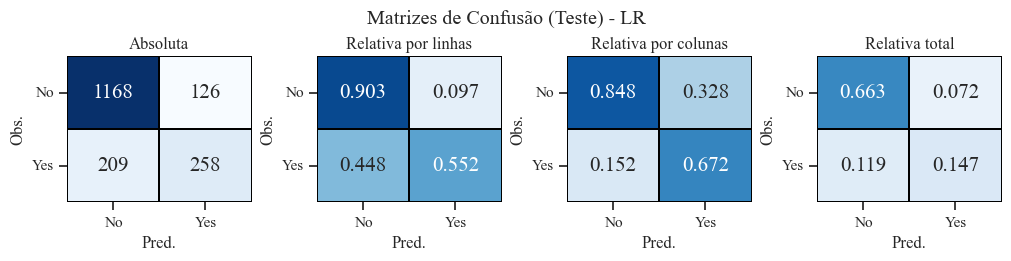

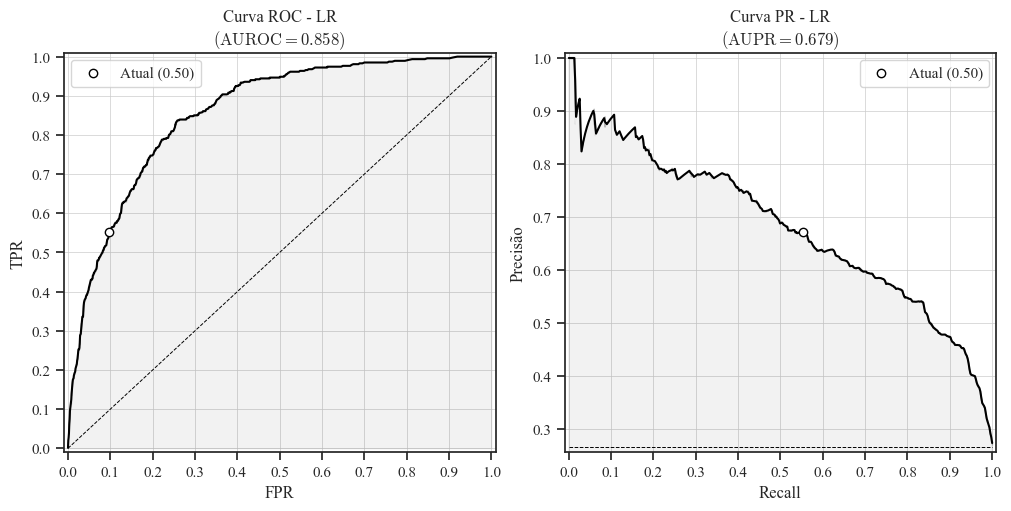

In [5]:
_ = evaluate(
    model=models['LR'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2, threshold=0.5, threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_pr_curve=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_pr_curve=True,
    path_metrics_table='../reports/tables/model-evaluation_LR.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_LR.png',
    path_roc_pr_curve='../reports/figures/roc-pr-curves_LR.png',
    model_title=' - LR')

## Árvore de Decisão (**DT**)

### Otimização de Hiperparâmetros

In [11]:
hyperparam_dist = {'ccp_alpha':stats.loguniform(a=1e-4, b=1e3),
                   'criterion':['gini', 'entropy'],
                   'min_samples_split':stats.randint(2, 40+1)}

df_hyperparam_optimization = parallelized_random_search_with_kfoldcv(model=DecisionTreeClassifier(random_state=7),
                                                                     n_comb=1000, k=5,
                                                                     transformer_X=transformers_X['DT'], transformer_y=transformer_y,
                                                                     df_X_train=df_X_train, df_y_train=df_y_train,
                                                                     hyperparam_distributions=hyperparam_dist,
                                                                     n_jobs=5,
                                                                     global_seed=7)

df_hyperparam_optimization.to_csv('../reports/tables/hyperparam-optimization_DT.csv')

display_best_hyperparam_combinations(df=df_hyperparam_optimization,
                                     n_best=None, sort_by='min_samples_split', ascending=False,
                                     with_one_standard_error_rule=True,
                                     metric_mean_column='auc (mean)',
                                     metric_se_column='auc (se)',
                                     style_format={'ccp_alpha':lambda x: ffp(x)})

Tempo Total: 37 s | 0.6 min | 0.0 h
             0h 00min 36s


,ccp_alpha,criterion,min_samples_split,auc (mean),auc (std),auc (se)
447,0.0028075893645747984,entropy,38,0.824055,0.008793,0.003932
415,0.002220981905763782,entropy,36,0.824147,0.010528,0.004708
184,0.0022261659343238895,entropy,36,0.824147,0.010528,0.004708
219,0.002071140208814707,entropy,32,0.824378,0.008559,0.003828
778,0.0020716321265925354,entropy,31,0.824378,0.008559,0.003828
908,0.0020280358191880976,entropy,31,0.823948,0.007217,0.003227
453,0.0026797550974218065,entropy,29,0.825207,0.009578,0.004283
378,0.0017907619083377857,entropy,24,0.822683,0.007146,0.003196
858,0.0018400565213841874,entropy,22,0.822622,0.007976,0.003567
187,0.0027797196395198728,entropy,18,0.824240,0.008740,0.003908


### Treinamento final e Avaliação

In [12]:
X_train_transformed = transformers_X['DT'].fit_transform(df_X_train)
X_test_transformed = transformers_X['DT'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [13]:
# Combinação de hiperparâmetros nº 447
models['DT'] = DecisionTreeClassifier(ccp_alpha=0.0028075893645747984,
                                      min_samples_split=38,
                                      criterion='entropy',
                                      random_state=7)

train_model(model=models['DT'],
            X=X_train_transformed, y=y_train.reshape(-1))

Tempo Total: 0 s | 0.0 min | 0.0 h
             0h 00min 00s


,Treinamento,Teste
Acurácia,0.791,0.793
Precisão,0.684,0.677
Recall,0.392,0.418
F1-Score,0.499,0.517
F2.-Score,0.429,0.452
AUROC,-----,0.837
AUPR,-----,0.665


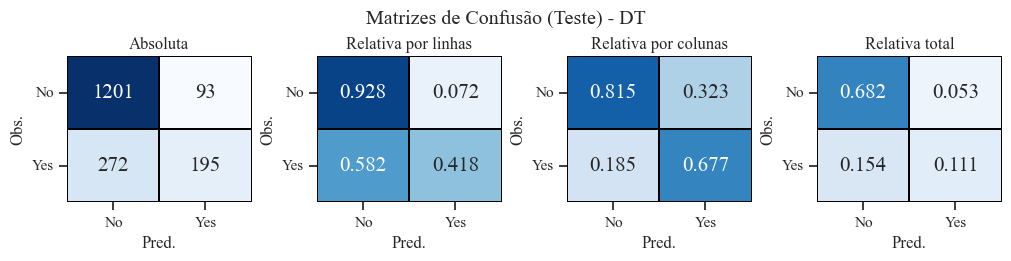

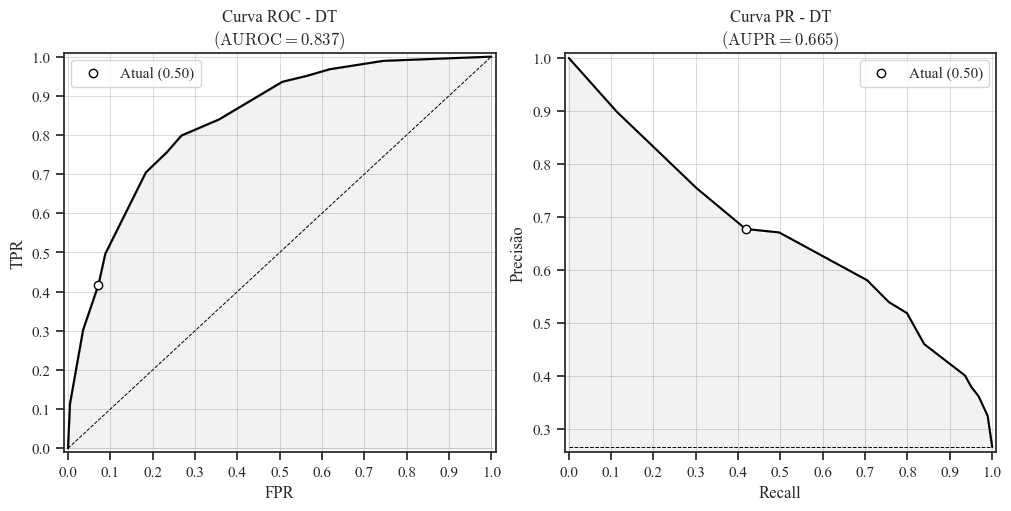

In [14]:
_ = evaluate(
    model=models['DT'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2, threshold=0.5, threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_pr_curve=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_pr_curve=True,
    path_metrics_table='../reports/tables/model-evaluation_DT.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_DT.png',
    path_roc_pr_curve='../reports/figures/roc-pr-curves_DT.png',
    model_title=' - DT')

## Floresta Aleatória (**RF**)

### Otimização de Hiperparâmetros

In [3]:
hyperparam_dist = {'n_estimators':stats.randint(10, 500+1),
                   'criterion':['gini', 'entropy'],
                   'max_features':stats.uniform(0, 1),
                   'max_depth':list(range(2, 20+1, 2)) + [None]}

df_hyperparam_optimization = random_search_with_kfoldcv(model=RandomForestClassifier(random_state=7, n_jobs=-1),
                                                        n_comb=100, k=5,
                                                        transformer_X=transformers_X['RF'], transformer_y=transformer_y,
                                                        df_X_train=df_X_train, df_y_train=df_y_train,
                                                        hyperparam_distributions=hyperparam_dist,
                                                        verbose_tqdm=True,
                                                        global_seed=7)
                                                        
df_hyperparam_optimization.to_csv('../reports/tables/hyperparam-optimization_RF.csv')

display_best_hyperparam_combinations(df=df_hyperparam_optimization,
                                     n_best=None, sort_by='n_estimators', ascending=True,
                                     with_one_standard_error_rule=True,
                                     metric_mean_column='auc (mean)',
                                     metric_se_column='auc (se)',
                                     style_format={'max_features':lambda x: ffp(x)})

Validação Cruzada K-Fold - 5/5: 100%|████████████████████████████████████████████████| 100/100 [41:59<00:00, 25.20s/it]


,n_estimators,criterion,max_features,max_depth,auc (mean),auc (std),auc (se)
66,20,gini,0.9649709995361269,4,0.836087,0.013742,0.006146
84,29,gini,0.7963907007825485,6,0.838938,0.012420,0.005554
46,48,gini,0.4129918291138346,4,0.837663,0.014061,0.006288
25,85,gini,0.13316944575925016,6,0.839375,0.013998,0.006260
38,122,gini,0.572625332643954,8,0.836204,0.011821,0.005287
67,243,gini,0.9450482237927939,6,0.840025,0.011601,0.005188
63,262,gini,0.30885268486379713,6,0.841160,0.012061,0.005394
43,322,gini,0.3703510829880352,4,0.838361,0.013479,0.006028
93,339,gini,0.8756717248700833,4,0.837889,0.013351,0.005971
7,358,gini,0.07205113335976154,6,0.838041,0.015226,0.006809


### Treinamento final e Avaliação

In [4]:
X_train_transformed = transformers_X['RF'].fit_transform(df_X_train)
X_test_transformed = transformers_X['RF'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [5]:
# Combinação de hiperparâmetros nº 66
models['RF'] = RandomForestClassifier(n_estimators=20,
                                      max_features=0.9649709995361269,
                                      criterion='gini',
                                      max_depth=4,
                                      n_jobs=-1,
                                      random_state=7)

train_model(model=models['RF'],
            X=X_train_transformed, y=y_train.reshape(-1))

Tempo Total: 2 s | 0.0 min | 0.0 h
             0h 00min 02s


,Treinamento,Teste
Acurácia,0.795,0.806
Precisão,0.674,0.696
Recall,0.444,0.475
F1-Score,0.535,0.565
F2.-Score,0.477,0.508
AUROC,-----,0.852
AUPR,-----,0.676


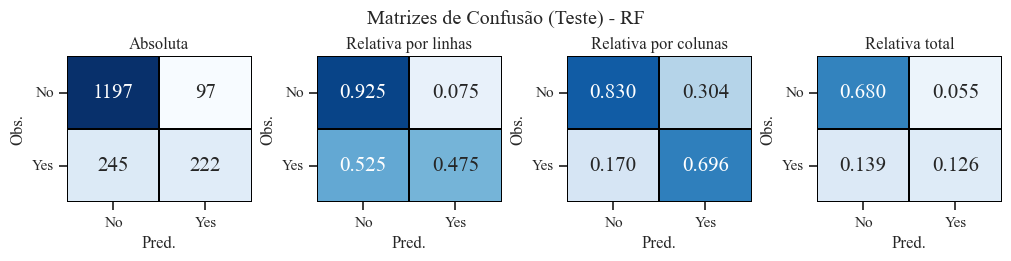

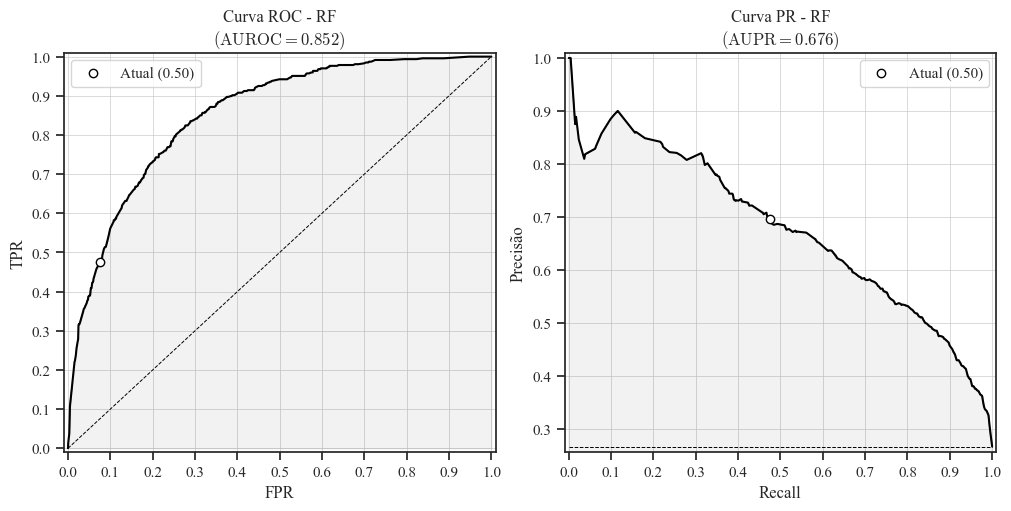

In [6]:
_ = evaluate(
    model=models['RF'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2, threshold=0.5, threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_pr_curve=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_pr_curve=True,
    path_metrics_table='../reports/tables/model-evaluation_RF.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_RF.png',
    path_roc_pr_curve='../reports/figures/roc-pr-curves_RF.png',
    model_title=' - RF')

## K-Vizinhos mais Próximos (**KNN**)

### Otimização de Hiperparâmetros

In [15]:
hyperparam_dist = {'n_neighbors':stats.randint(1, 200+1),
                   'weights':['uniform', 'distance'],
                   'p':stats.randint(1, 5+1)}

df_hyperparam_optimization = parallelized_random_search_with_kfoldcv(model=KNeighborsClassifier(metric='minkowski'),
                                                                     n_comb=1000, k=5,
                                                                     transformer_X=transformers_X['KNN'], transformer_y=transformer_y,
                                                                     df_X_train=df_X_train, df_y_train=df_y_train,
                                                                     hyperparam_distributions=hyperparam_dist,
                                                                     n_jobs=5,
                                                                     global_seed=7)
                                                                     
df_hyperparam_optimization.to_csv('../reports/tables/hyperparam-optimization_KNN.csv')

display_best_hyperparam_combinations(df=df_hyperparam_optimization,
                                     n_best=10, sort_by='n_neighbors', ascending=True,
                                     with_one_standard_error_rule=True,
                                     metric_mean_column='auc (mean)',
                                     metric_se_column='auc (se)',
                                     style_format={})

Tempo Total: 1120 s | 18.7 min | 0.3 h
             0h 18min 40s


,n_neighbors,weights,p,auc (mean),auc (std),auc (se)
922,24,uniform,3,0.824958,0.012409,0.005550
9,24,uniform,3,0.824958,0.012409,0.005550
584,25,uniform,3,0.824960,0.012772,0.005712
543,26,uniform,5,0.825402,0.010915,0.004881
437,27,uniform,2,0.825323,0.012829,0.005737
656,27,uniform,3,0.825474,0.013194,0.005900
129,27,uniform,5,0.825761,0.011015,0.004926
789,28,uniform,1,0.825351,0.013385,0.005986
527,29,uniform,5,0.825991,0.011473,0.005131
406,29,uniform,1,0.825806,0.013680,0.006118


### Treinamento final e Avaliação

In [16]:
X_train_transformed = transformers_X['KNN'].fit_transform(df_X_train)
X_test_transformed = transformers_X['KNN'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [17]:
# Combinação nº 9 de hiperparâmetros
models['KNN'] = KNeighborsClassifier(n_neighbors=24,
                                     weights='uniform',
                                     p=3,
                                     metric='minkowski',
                                     n_jobs=-1)

train_model(model=models['KNN'],
            X=X_train_transformed, y=y_train.reshape(-1))

Tempo Total: 0 s | 0.0 min | 0.0 h
             0h 00min 00s


,Treinamento,Teste
Acurácia,0.801,0.802
Precisão,0.629,0.626
Recall,0.613,0.630
F1-Score,0.621,0.628
F2.-Score,0.616,0.629
AUROC,-----,0.841
AUPR,-----,0.632


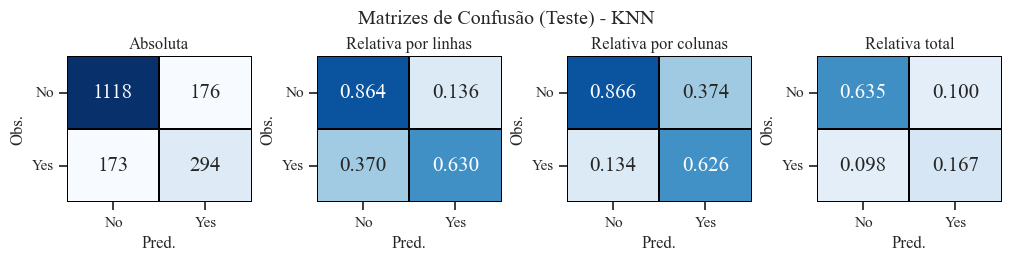

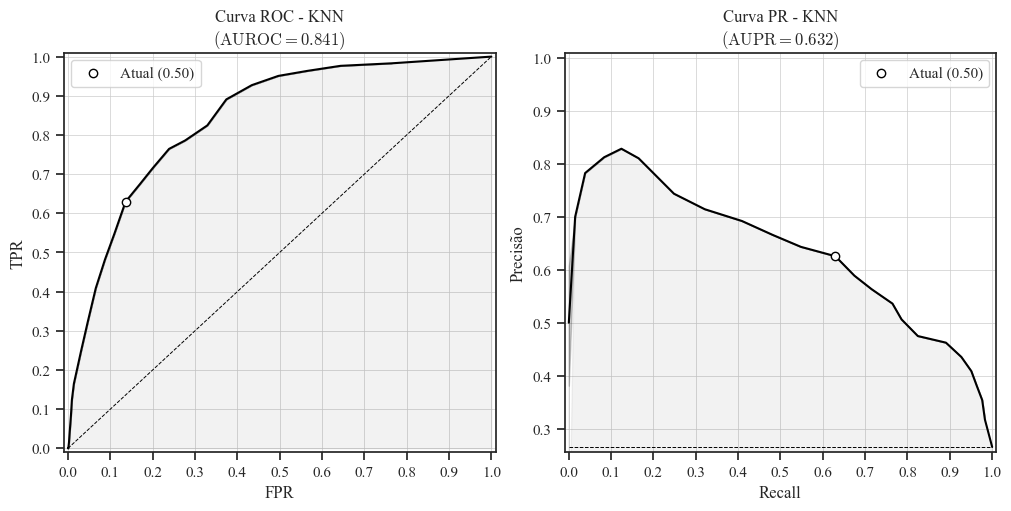

In [18]:
_ = evaluate(
    model=models['KNN'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2, threshold=0.5, threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_pr_curve=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_pr_curve=True,
    path_metrics_table='../reports/tables/model-evaluation_KNN.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_KNN.png',
    path_roc_pr_curve='../reports/figures/roc-pr-curves_KNN.png',
    model_title=' - KNN')

## Máquinas de Vetores de Suporte (**SVM**)

### Otimização de Hiperparâmetros

In [19]:
hyperparam_dist = {'C':stats.loguniform(2**-10, 2**10),
                   'gamma':stats.loguniform(2**-20, 2**5)}

df_hyperparam_optimization = parallelized_random_search_with_kfoldcv(model=SVC(random_state=7, kernel='rbf', probability=True),
                                                                     n_comb=100, k=5,
                                                                     transformer_X=transformers_X['SVM'], transformer_y=transformer_y,
                                                                     df_X_train=df_X_train, df_y_train=df_y_train,
                                                                     hyperparam_distributions=hyperparam_dist,
                                                                     n_jobs=5,
                                                                     global_seed=7)
                                                                     
df_hyperparam_optimization.to_csv('../reports/tables/hyperparam-optimization_SVM.csv')

display_best_hyperparam_combinations(df=df_hyperparam_optimization,
                                     n_best=10, sort_by=None, ascending=False,
                                     with_one_standard_error_rule=False,
                                     metric_mean_column='auc (mean)',
                                     metric_se_column='auc (se)',
                                     style_format={'C':lambda x:ffp(x), 'gamma':lambda x:ffp(x)})

Tempo Total: 1045 s | 17.4 min | 0.3 h
             0h 17min 25s


,C,gamma,auc (mean),auc (std),auc (se)
80,0.009685404441990337,0.00001678503431063868,0.831205,0.019588,0.008760
56,0.003508930082791008,0.000004717842365609852,0.831203,0.019377,0.008666
7,0.002651496698028075,0.0000033238307076191213,0.831201,0.019271,0.008618
48,0.011915905388383753,0.00002174872692658874,0.831199,0.019265,0.008616
55,0.0009960719731237507,0.0000009775487685593361,0.831169,0.019503,0.008722
0,0.002812689058414437,0.0000035783036151318345,0.831123,0.019511,0.008726
71,0.0060126339578758774,0.000009249238731931034,0.831092,0.019365,0.008660
30,0.0167114624961116,0.00003319274013141588,0.831090,0.019495,0.008718
92,0.0017158226880264926,0.00000192914796952792,0.831082,0.019418,0.008684
76,0.0065129297278917414,0.000010221050238172716,0.831036,0.019403,0.008677


### Treinamento final e Avaliação

In [20]:
X_train_transformed = transformers_X['SVM'].fit_transform(df_X_train)
X_test_transformed = transformers_X['SVM'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [21]:
# Combinação nº 80 de hiperparâmetros
models['SVM'] = SVC(C=0.009685404441990337,
                    gamma=0.00001678503431063868,
                    kernel='rbf',
                    probability=True,
                    random_state=7)

train_model(model=models['SVM'],
            X=X_train_transformed, y=y_train.reshape(-1))

Tempo Total: 4 s | 0.1 min | 0.0 h
             0h 00min 04s


,Treinamento,Teste
Acurácia,0.791,0.798
Precisão,0.614,0.628
Recall,0.572,0.585
F1-Score,0.592,0.605
F2.-Score,0.580,0.593
AUROC,-----,0.846
AUPR,-----,0.665


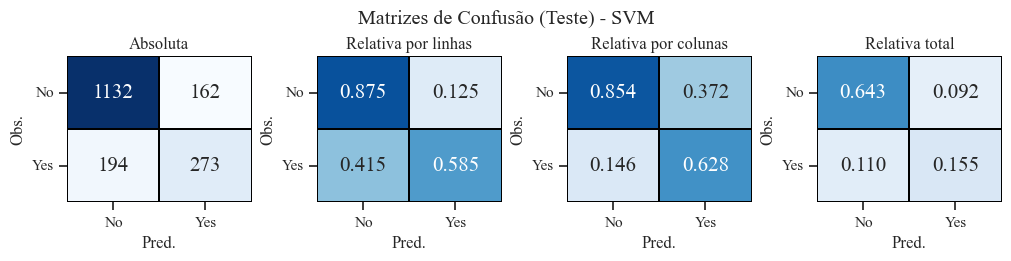

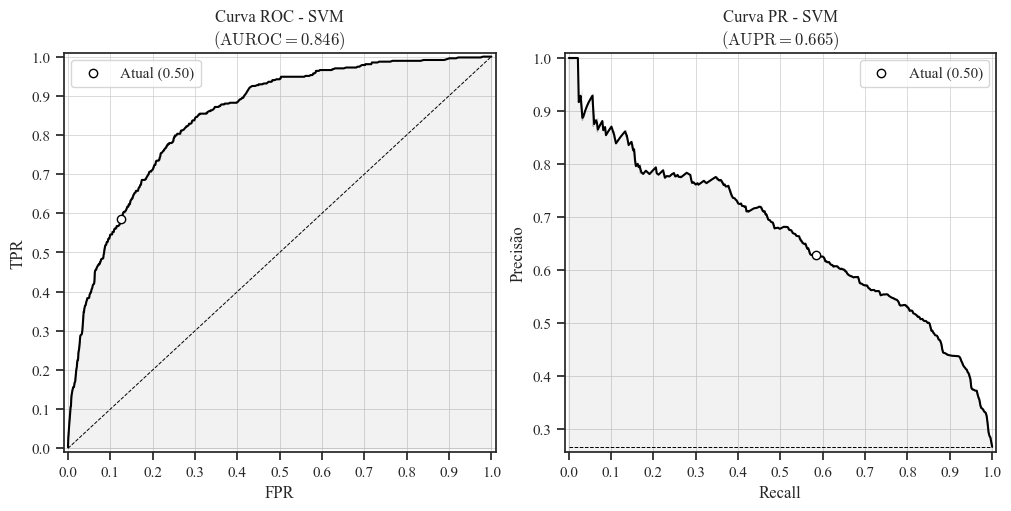

In [22]:
_ = evaluate(
    model=models['SVM'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2, threshold=0.5, threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_pr_curve=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_pr_curve=True,
    path_metrics_table='../reports/tables/model-evaluation_SVM.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_SVM.png',
    path_roc_pr_curve='../reports/figures/roc-pr-curves_SVM.png',
    model_title=' - SVM')

# Salvando e Carregando os Modelos Treinados

In [7]:
save_models(models_dict=models, path='../models/', format='.pkl')

In [3]:
models = load_models(models_names=['LR', 'DT', 'KNN', 'RF', 'SVM'], path='../models/', format='.pkl')